# Klein Filters

In the paper [Topological Convolutional Layers for Deep Learning](https://www.jmlr.org/papers/volume24/21-0073/21-0073.pdf#10) Love et al define a function $F_K$ that maps Klein bottle into the space of quadratic functions on $[-1,1]^2$. This map is given by 

$$
\begin{align*}
F_K(\theta_1, \theta_2)(x,y) &= \sin(\theta_2)\left( \cos(\theta_1)x + \sin(\theta_1)y \right)
+ \cos(\theta_2) Q\left( \cos(\theta_1)x + \sin(\theta_1)y \right) = \\
&= \begin{bmatrix} \sin(\theta_2) & \cos(\theta_2) \end{bmatrix} \begin{bmatrix} t \\ Q(t) \end{bmatrix}
\end{align*}
$$

where $t = \cos(\theta_1)x + \sin(\theta_1)y = (x,y)\cdot\left( \cos \theta_1, \sin \theta_1 \right)$ and $Q$ is the degree-2 Chebyshev polynomial defined as 

$$
Q(t) = 2t^2 - 1.
$$

As given, $F_K$ is a function on **2-dimensional torus** $S^1\times S^1$, parametrized by angles $\theta_1$ and $\theta_2$ correspondingly. However it is straightforward to see that $F_K$ satisfies the following properties:
1. $F_K(\theta_1, \theta_2) = F_K(\theta_1 + 2\pi k, \theta_2 + 2\pi l)$,
2. $F_K(\theta_1, \theta_2) = F_K(\theta_1 + \pi, -\theta_2)$.

Therefore it actually defines a function on a **Klein bottle** $K$.

In [4]:
import numpy as np
from scipy.integrate import dblquad
from scipy.stats.qmc import Sobol
from sklearn.metrics import pairwise_distances

from ripser import ripser
from persim import plot_diagrams
from gudhi.dtm_rips_complex import DTMRipsComplex

from collections import defaultdict

import umap
import plotly.graph_objs as go
import matplotlib.pyplot as plt



/Users/snopoff/Documents/Research/KleinVAE/.venv/lib/python3.13/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


In [5]:
def projection_onto_a_line(theta: float) -> float:
    """
    Creates a function that projects a point onto a line.
    """
    return lambda x,y: (x * np.cos(theta) + y * np.sin(theta))
    

def chebyshev_2(t: float) -> float:
    """
    Chebyshev polynomial of the 2nd degree.
    """
    return 2 * t**2 - 1


def klein_filter(theta_1: float, theta_2: float) -> float:
    """
    Klein filter for given angles theta_1 and theta_2.
    """
    t = projection_onto_a_line(theta_1)
    return lambda x,y: np.sin(theta_2) * t(x,y) + np.cos(theta_2) * chebyshev_2(t(x,y))

In [6]:
def generate_klein_filter_matrix(theta_1, theta_2, size=3, midpoint=True):
    """
    Generate a Klein filter matrix of given size for specified angles.

    Parameters:
    - theta_1: Angle for the first projection.
    - theta_2: Angle for the second projection.
    - size: Size of the matrix.
    - midpoint: If True, use midpoints for the grid; otherwise, use edges.
    """
    f = klein_filter(theta_1, theta_2)
    coords = np.linspace(-1 + 1/size, 1 - 1/size, size) if midpoint else np.linspace(-1, 1, size)
    X, Y = np.meshgrid(coords, coords)
    Z = f(X, Y)
    return Z

def generate_klein_filter_matrix_via_integration(theta_1, theta_2, size=3):
    """
    Generate a Klein filter matrix of given size for specified angles using integration.
    """
    f = klein_filter(theta_1, theta_2)
    result = np.zeros([size, size])
    for x in range(size):
        for y in range(size):
            xmin = -1.0 + ((2 * x) / (2 * size))
            xmax = -1.0 + ((2 * (x + 1.0)) / (2 * size))
            ymin = -1.0 + ((2 * y) / (2 * size))
            ymax = -1.0 + ((2 * (y + 1.0)) / (2 * size))

            Filter = dblquad(f, xmin, xmax, ymin, ymax)[0]
            result[y][x] = Filter

    return result

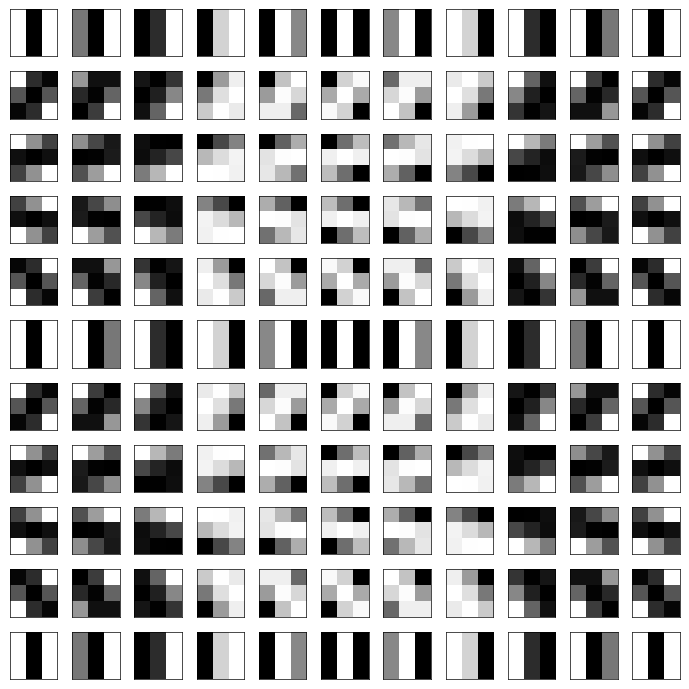

In [8]:
n = 10

fig, axes = plt.subplots(n+1, n+1, figsize=(7, 7))
for i in range(0, n+1):
    for j in range(0, n+1):
        theta_1 = 2 * np.pi * i / n
        theta_2 = 2 * np.pi * j / n
        filter_img = generate_klein_filter_matrix(theta_1, theta_2, size=3, midpoint=False)
        #filter_img = generate_klein_filter_matrix_via_integration(theta_1, theta_2, size=3)
        axes[i, j].imshow(filter_img, cmap='gray', extent=[-1, 1, -1, 1])
        # Draw black border
        for spine in axes[i, j].spines.values():
            spine.set_edgecolor('black')
            spine.set_linewidth(0.5)
        axes[i, j].set_xticks([])
        axes[i, j].set_yticks([])

plt.tight_layout()
plt.show()

Notice that the $F_K$ indeed satsfies the properties: the filters in the bottom are sort of "mirrored" from the filters from above: this is an illustration of the second property, and the first row/column coincides with the last row/column - the first property in action.

## Persistent Homology of Filters
Let's flatten these images and check the homology of the point cloud in $\R^9$ we will get. Ideally we will get the homology of Klein bottle:
$$
H_i(K;\Z) = 
\begin{cases}
\Z, \text{ if } i=0 \\
\Z \oplus \Z/2, \text{ if } i=1 \\
0, \text{ otherwise.}
\end{cases}
$$

`ripser` allows us to compute the homology over the finite field. We will do it over $\Z/2$ and $\Z/3$, since, using UCT:

$$
H_i(K;\Z/2) = 
\begin{cases}
\Z/2, \text{ if } i=0 \\
\Z/2 \oplus \Z/2, \text{ if } i=1 \\
0, \text{ otherwise.}
\end{cases}
$$

But

$$
H_i(K;\Z/3) = 
\begin{cases}
\Z/3, \text{ if } i=0,1 \\
0, \text{ otherwise.}
\end{cases}
$$


Let $\theta_1$ runs up to $\pi$.
So we should get the homology of the Klein bottle as above

In [15]:
n_angles = 10_000

th1s = np.random.uniform(0, np.pi, n_angles)
th2s = np.random.uniform(0, 2*np.pi, n_angles)

In [16]:
filters = [None]*n_angles

for i, thetas in enumerate(zip(th1s, th2s)):
    theta_1, theta_2 = thetas
    klein_filter_matrix = generate_klein_filter_matrix(theta_1, theta_2, size=3, midpoint=False)
    #klein_filter_matrix = generate_klein_filter_matrix_via_integration(theta_1, theta_2, size=3)
    filters[i] = klein_filter_matrix.flatten()
    
X = np.array(filters)
X.shape

(10000, 9)

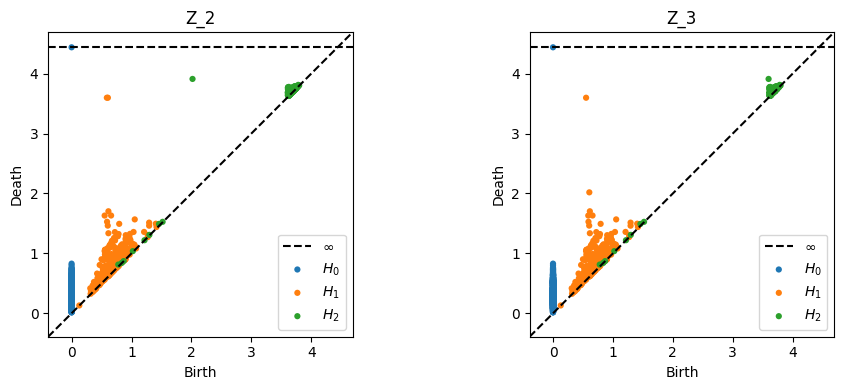

CPU times: user 1min 34s, sys: 3.3 s, total: 1min 37s
Wall time: 1min 37s


In [7]:
%%time

diagrams2 = ripser(X, coeff=2, maxdim=2)['dgms']
diagrams3 = ripser(X, coeff=3, maxdim=2)['dgms']

fig, axes = plt.subplots(1, 2, figsize=(10, 4))

axes[0].set_title('Z_2')
plot_diagrams(diagrams2, ax=axes[0], show=False)

axes[1].set_title('Z_3')
plot_diagrams(diagrams3, ax=axes[1], show=False)

plt.tight_layout()
plt.show()

<>:3: SyntaxWarning: invalid escape sequence '\m'
<>:6: SyntaxWarning: invalid escape sequence '\m'
<>:3: SyntaxWarning: invalid escape sequence '\m'
<>:6: SyntaxWarning: invalid escape sequence '\m'
/var/folders/dn/583y80ks1x9c_5n961lfvw840000gn/T/ipykernel_18722/3935299713.py:3: SyntaxWarning: invalid escape sequence '\m'
  axes[0].set_title('$\mathbb{Z}_2$')
/var/folders/dn/583y80ks1x9c_5n961lfvw840000gn/T/ipykernel_18722/3935299713.py:6: SyntaxWarning: invalid escape sequence '\m'
  axes[1].set_title('$\mathbb{Z}_3$')


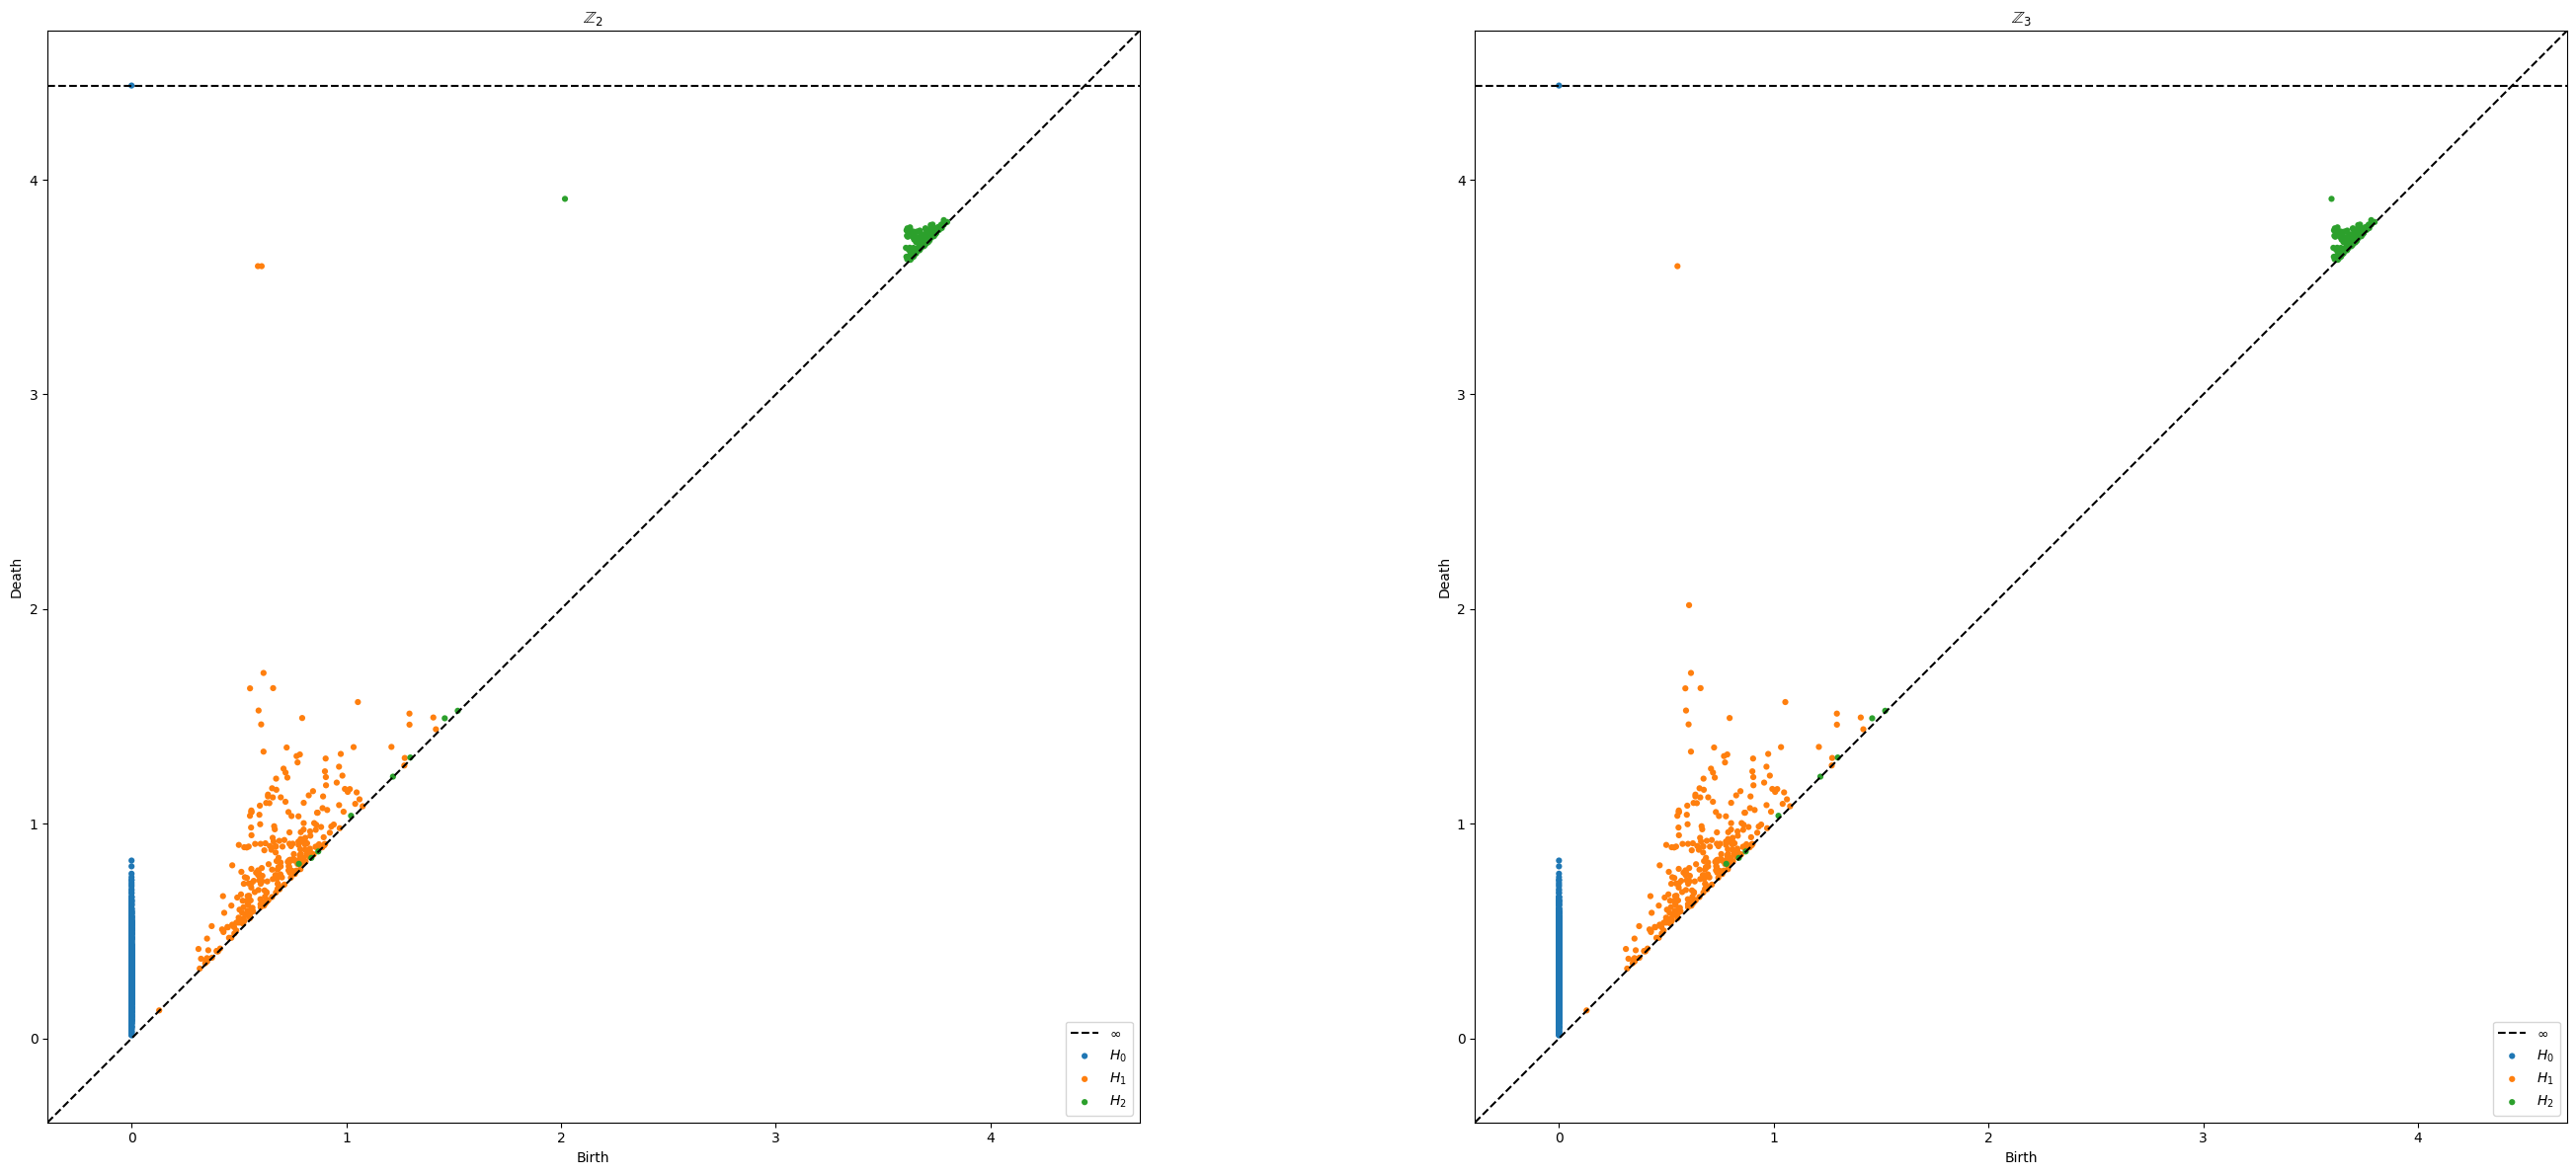

In [26]:
fig, axes = plt.subplots(1, 2, figsize=(30, 12))

axes[0].set_title('$\mathbb{Z}_2$')
plot_diagrams(diagrams2, ax=axes[0], show=False)

axes[1].set_title('$\mathbb{Z}_3$')
plot_diagrams(diagrams3, ax=axes[1], show=False)

plt.tight_layout()
plt.show()

In [19]:
lifespan_of_1cycles = sorted([d - b for b,d in diagrams2[1]], reverse=True)
lifespan_of_1cycles

[np.float64(3.0092150568962097),
 np.float64(2.9917356967926025),
 np.float64(1.0879042148590088),
 np.float64(1.0790465474128723),
 np.float64(0.9724526405334473),
 np.float64(0.9360008239746094),
 np.float64(0.859379231929779),
 np.float64(0.7214443683624268),
 np.float64(0.6980562806129456),
 np.float64(0.6329852342605591),
 np.float64(0.548944890499115),
 np.float64(0.5467571020126343),
 np.float64(0.5389004349708557),
 np.float64(0.5372046232223511),
 np.float64(0.5215088129043579),
 np.float64(0.5130133628845215),
 np.float64(0.5126697421073914),
 np.float64(0.5108528733253479),
 np.float64(0.5040850043296814),
 np.float64(0.5005822777748108),
 np.float64(0.49631810188293457),
 np.float64(0.49626481533050537),
 np.float64(0.49218761920928955),
 np.float64(0.4896324872970581),
 np.float64(0.48692989349365234),
 np.float64(0.4856299161911011),
 np.float64(0.48401784896850586),
 np.float64(0.47024476528167725),
 np.float64(0.4649556875228882),
 np.float64(0.4542697072029114),
 np.fl

/Users/snopoff/Documents/Research/KleinVAE/.venv/lib/python3.13/site-packages/sklearn/utils/deprecation.py:151: FutureWarning: 'force_all_finite' was renamed to 'ensure_all_finite' in 1.6 and will be removed in 1.8.
  warnings.warn(
/Users/snopoff/Documents/Research/KleinVAE/.venv/lib/python3.13/site-packages/umap/umap_.py:1952: UserWarning: n_jobs value 1 overridden to 1 by setting random_state. Use no seed for parallelism.
  warn(
/Users/snopoff/Documents/Research/KleinVAE/.venv/lib/python3.13/site-packages/sklearn/utils/deprecation.py:151: FutureWarning: 'force_all_finite' was renamed to 'ensure_all_finite' in 1.6 and will be removed in 1.8.
  warnings.warn(


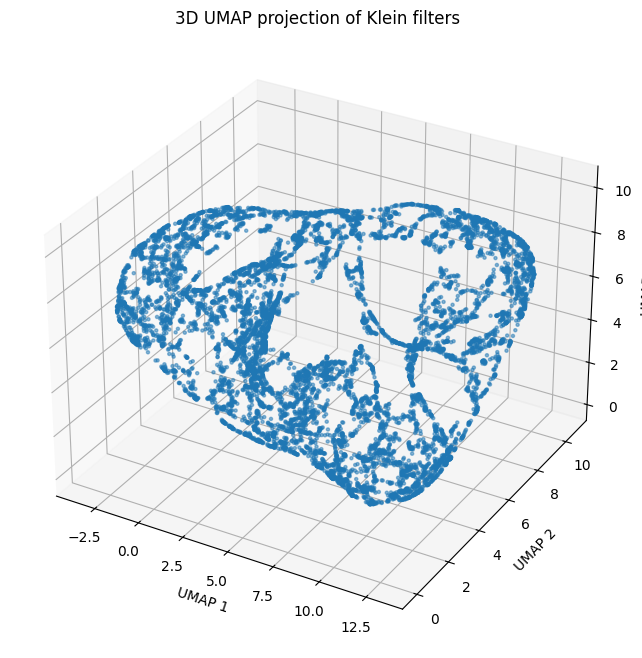

CPU times: user 6.45 s, sys: 24.9 ms, total: 6.47 s
Wall time: 6.52 s


In [18]:
%%time

reducer = umap.UMAP(n_components=3, random_state=28)
reducer.fit(X)
klein_embedding = reducer.transform(X)

fig = plt.figure(figsize=(10, 8))
ax = fig.add_subplot(111, projection='3d')
ax.scatter(klein_embedding[:, 0], klein_embedding[:, 1], klein_embedding[:, 2], s=5, alpha=0.5)
ax.set_title('3D UMAP projection of Klein filters')
ax.set_xlabel('UMAP 1')
ax.set_ylabel('UMAP 2')
ax.set_zlabel('UMAP 3')
plt.show()

#### Additional: $\theta_1$ runs up to $2\pi$
We really should just get the same

In [29]:
n_angles = 1_000

th1s = np.random.uniform(0, 2 * np.pi, n_angles)
th2s = np.random.uniform(0, 2 * np.pi, n_angles)

In [30]:
filters = [None]*n_angles

for i, thetas in enumerate(zip(th1s, th2s)):
    theta_1, theta_2 = thetas
    klein_filter_matrix = generate_klein_filter_matrix_via_integration(theta_1, theta_2, size=3)
    filters[i] = klein_filter_matrix.flatten()
    
X = np.array(filters)
X.shape

(1000, 9)

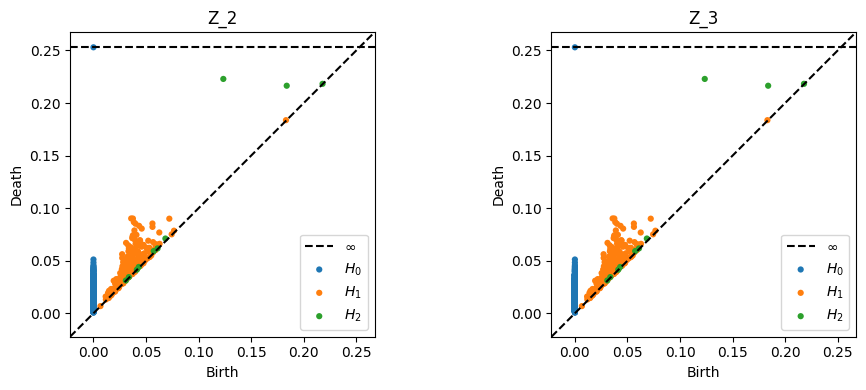

In [31]:
diagrams2 = ripser(X, coeff=2, maxdim=2)['dgms']
diagrams3 = ripser(X, coeff=3, maxdim=2)['dgms']

fig, axes = plt.subplots(1, 2, figsize=(10, 4))

axes[0].set_title('Z_2')
plot_diagrams(diagrams2, ax=axes[0], show=False)

axes[1].set_title('Z_3')
plot_diagrams(diagrams3, ax=axes[1], show=False)

plt.tight_layout()
plt.show()

## Comparing to DWP-data


In [21]:
y = np.load('dwp-data/conv5x5/test.npy')[:,0,:,:]

y /= np.linalg.norm(y, axis = (1,2))[np.newaxis,np.newaxis].T
y = y.reshape(y.shape[0], -1)
size = int(np.sqrt(y.shape[1]))
y.shape

(20448, 25)

In [22]:
thetas = Sobol(d=2).random(20448)

thetas *= 2*np.pi

xs = np.linspace(-1, 1, size)
ys = np.linspace(-1, 1, size)
xv, yv = np.meshgrid(xs, ys)

klein_matrices = []

for i in range(2048):
    filter_ = generate_klein_filter_matrix(thetas[i,0],thetas[i,1], size=size, midpoint=False)
    klein_matrices.append(filter_.flatten())
    
klein_matrices = np.array(klein_matrices)

klein_matrices /= np.linalg.norm(klein_matrices, axis = (1))[np.newaxis].T

/Users/snopoff/Documents/Research/KleinVAE/.venv/lib/python3.13/site-packages/scipy/stats/_qmc.py:993: UserWarning: The balance properties of Sobol' points require n to be a power of 2.
  sample = self._random(n, workers=workers)


/Users/snopoff/Documents/Research/KleinVAE/.venv/lib/python3.13/site-packages/sklearn/utils/extmath.py:203: RuntimeWarning: divide by zero encountered in matmul
  ret = a @ b
/Users/snopoff/Documents/Research/KleinVAE/.venv/lib/python3.13/site-packages/sklearn/utils/extmath.py:203: RuntimeWarning: overflow encountered in matmul
  ret = a @ b
/Users/snopoff/Documents/Research/KleinVAE/.venv/lib/python3.13/site-packages/sklearn/utils/extmath.py:203: RuntimeWarning: invalid value encountered in matmul
  ret = a @ b


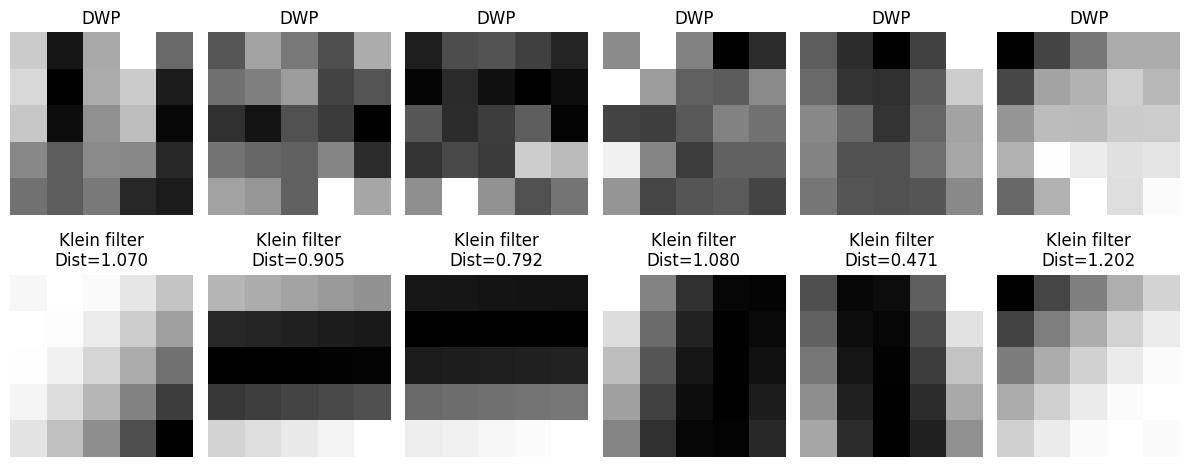

In [23]:
n_examples = 6
ds = pairwise_distances(y, klein_matrices)
indices = np.random.choice(20448, n_examples, replace=False)

fig, axes = plt.subplots(2, n_examples, figsize=(2 * n_examples, 5))

for col, i in enumerate(indices):
    # DWP filter
    axes[0, col].imshow(y[i, :].reshape((size, size)), cmap='gray')
    axes[0, col].set_title('DWP')
    axes[0, col].axis('off')
    
    # Closest Klein filter
    j_nearest = np.argmin(ds[i, :])
    axes[1, col].imshow(klein_matrices[j_nearest].reshape((size, size)), cmap='gray')
    dist = ds[i, j_nearest]
    axes[1, col].set_title(f'Klein filter\nDist={dist:.3f}')
    axes[1, col].axis('off')

plt.tight_layout()
plt.show()


/Users/snopoff/Documents/Research/KleinVAE/.venv/lib/python3.13/site-packages/sklearn/utils/extmath.py:203: RuntimeWarning: divide by zero encountered in matmul
  ret = a @ b
/Users/snopoff/Documents/Research/KleinVAE/.venv/lib/python3.13/site-packages/sklearn/utils/extmath.py:203: RuntimeWarning: overflow encountered in matmul
  ret = a @ b
/Users/snopoff/Documents/Research/KleinVAE/.venv/lib/python3.13/site-packages/sklearn/utils/extmath.py:203: RuntimeWarning: invalid value encountered in matmul
  ret = a @ b
/Users/snopoff/Documents/Research/KleinVAE/.venv/lib/python3.13/site-packages/sklearn/utils/deprecation.py:151: FutureWarning: 'force_all_finite' was renamed to 'ensure_all_finite' in 1.6 and will be removed in 1.8.
  warnings.warn(
/Users/snopoff/Documents/Research/KleinVAE/.venv/lib/python3.13/site-packages/umap/umap_.py:1952: UserWarning: n_jobs value 1 overridden to 1 by setting random_state. Use no seed for parallelism.
  warn(


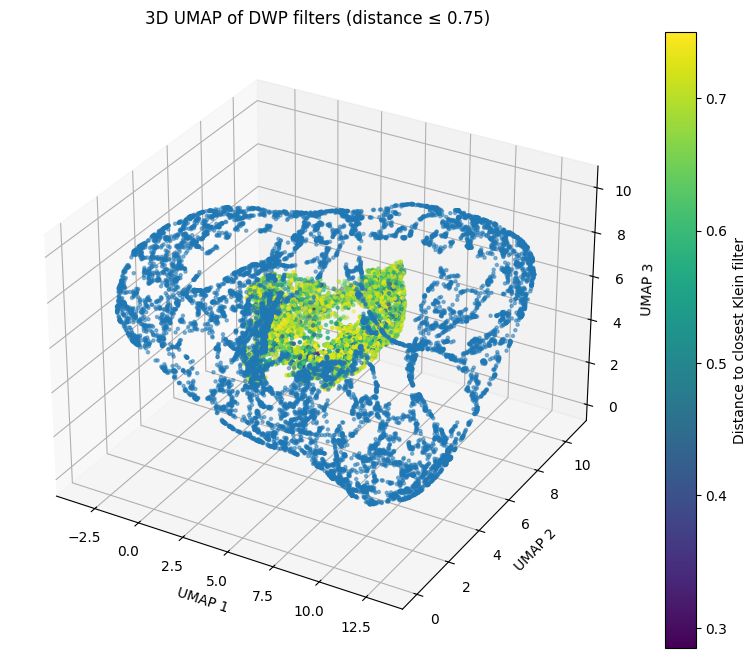

CPU times: user 3.68 s, sys: 56.2 ms, total: 3.74 s
Wall time: 3.77 s


: 

In [ ]:
%%time

threshold = 0.75  # Set your desired threshold here

ds = pairwise_distances(y, klein_matrices)
min_distances = np.min(ds, axis=1)

# Mask for points below the threshold
mask = min_distances <= threshold
y_filtered = y[mask]
min_distances_filtered = min_distances[mask]

# Filtered embeddings and distances
reducer = umap.UMAP(n_components=3, random_state=28)
embedding_filtered = reducer.fit_transform(y_filtered)


fig = plt.figure(figsize=(10, 8))
ax = fig.add_subplot(111, projection='3d')
sc = ax.scatter(
    embedding_filtered[:, 0],
    embedding_filtered[:, 1],
    embedding_filtered[:, 2],
    c=min_distances_filtered,
    cmap='viridis',
    s=5
)

ax.scatter(klein_embedding[:, 0], klein_embedding[:, 1], klein_embedding[:, 2], s=5, alpha=0.5)

fig.colorbar(sc, label='Distance to closest Klein filter')
ax.set_title(f'3D UMAP of DWP filters (distance ≤ {threshold})')
ax.set_xlabel('UMAP 1')
ax.set_ylabel('UMAP 2')
ax.set_zlabel('UMAP 3')
plt.show()

In [ ]:
%%time

diagrams2 = ripser(y_filtered, coeff=2, maxdim=2)['dgms']
diagrams3 = ripser(y_filtered, coeff=3, maxdim=2)['dgms']

fig, axes = plt.subplots(1, 2, figsize=(10, 4))

axes[0].set_title('Z_2')
plot_diagrams(diagrams2, ax=axes[0], show=False)

axes[1].set_title('Z_3')
plot_diagrams(diagrams3, ax=axes[1], show=False)

plt.tight_layout()
plt.show()

# End